<a href="https://colab.research.google.com/github/Shifali1094/stance-detection/blob/main/notebooks/bertweet_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# =========================
# 1. Install libraries
# =========================
!pip install -q transformers datasets evaluate accelerate emoji vncorenlp
!git clone https://github.com/Shifali1094/stance-detection.git

fatal: destination path 'stance-detection' already exists and is not an empty directory.


In [25]:
# =========================
# 2. Imports
# =========================
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

In [26]:
# =========================
# 3. Load dataset
# =========================

TEXT_COL = "text"
LABEL_COL = "label"

train_df = pd.read_csv("/content/stance-detection/train.csv")
val_df = pd.read_csv("/content/stance-detection/val.csv")
test_df = pd.read_csv("/content/stance-detection/test.csv")

train_df = train_df[[TEXT_COL, LABEL_COL]].dropna()
val_df = val_df[[TEXT_COL, LABEL_COL]].dropna()
test_df = test_df[[TEXT_COL, LABEL_COL]].dropna()

train_df[TEXT_COL] = train_df[TEXT_COL].astype(str)
val_df[TEXT_COL] = val_df[TEXT_COL].astype(str)
test_df[TEXT_COL] = test_df[TEXT_COL].astype(str)

print(train_df.head())

                                                text  label
0  Atheism [SEP] dear lord thank u for all of ur ...      2
1  Atheism [SEP] blessed are the peacemakers, for...      2
2  Atheism [SEP] i am not conformed to this world...      2
3  Atheism [SEP] salah should be prayed with #foc...      2
4  Atheism [SEP] papa god, i pray that you shower...      2


In [27]:
# =========================
# 4. Label encoding
# =========================

labels = sorted(train_df[LABEL_COL].unique().tolist())

# Convert labels to normal Python values / strings
labels = [str(label) for label in labels]

train_df[LABEL_COL] = train_df[LABEL_COL].astype(str)
val_df[LABEL_COL] = val_df[LABEL_COL].astype(str)
test_df[LABEL_COL] = test_df[LABEL_COL].astype(str)

label2id = {label: int(i) for i, label in enumerate(labels)}
id2label = {int(i): str(label) for label, i in label2id.items()}

train_df["labels"] = train_df[LABEL_COL].map(label2id).astype(int)
val_df["labels"] = val_df[LABEL_COL].map(label2id).astype(int)
test_df["labels"] = test_df[LABEL_COL].map(label2id).astype(int)

print("Labels:", label2id)
print(train_df["labels"].value_counts())

Labels: {'0': 0, '1': 1, '2': 2}
labels
2    1143
1     534
0     483
Name: count, dtype: int64


In [28]:
# =========================
# 5. Convert to Hugging Face Dataset
# =========================

from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[[TEXT_COL, "labels"]]
)

val_dataset = Dataset.from_pandas(
    val_df[[TEXT_COL, "labels"]]
)

test_dataset = Dataset.from_pandas(
    test_df[[TEXT_COL, "labels"]]
)

In [29]:
# =========================
# 6. Load tokenizer
# =========================

from transformers import AutoTokenizer

MODEL_NAME = "vinai/bertweet-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False,
    normalization=True
)

def tokenize_function(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/2160 [00:00<?, ? examples/s]

Map:   0%|          | 0/359 [00:00<?, ? examples/s]

Map:   0%|          | 0/1080 [00:00<?, ? examples/s]

In [30]:
# =========================
# 7. Load BERTweet model
# =========================

from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

In [31]:
# =========================
# 8. Metrics function
# =========================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):

    logits, y_true = eval_pred

    y_pred = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    acc = accuracy_score(y_true, y_pred)

    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

In [32]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bertweet_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=1e-5,     # lower than before
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,     # give it more time to balance
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=25,
    report_to="none",
    seed=42
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [33]:
import torch
from torch import nn
from transformers import Trainer

# Compute inverse-frequency weights from training labels
class_counts = train_df["labels"].value_counts().sort_index().values
print("Class counts:", class_counts)

# Inverse frequency, then normalise so they sum to num_classes
weights = len(class_counts) / (class_counts * class_counts.sum())
class_weights_tensor = torch.tensor(weights, dtype=torch.float)
print("Class weights:", class_weights_tensor)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(logits.device)
        )
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Weighted trainer created, class weights applied")

Class counts: [ 483  534 1143]
Class weights: tensor([2.8755e-06, 2.6009e-06, 1.2151e-06])
Weighted trainer created, class weights applied


In [34]:
# =========================
# 11. Train model
# =========================

train_result = trainer.train()

print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,1.037006,0.935001,0.548747,0.535353,0.579456,0.526858
2,0.819496,0.799911,0.565460,0.616291,0.621512,0.562679
3,0.695898,0.742592,0.632312,0.644010,0.674276,0.616349
4,0.601675,0.728095,0.676880,0.671609,0.690254,0.643453
5,0.539832,0.712612,0.693593,0.675780,0.690011,0.651248


TrainOutput(global_step=675, training_loss=0.7637056548507125, metrics={'train_runtime': 162.8815, 'train_samples_per_second': 66.306, 'train_steps_per_second': 4.144, 'total_flos': 377403308553600.0, 'train_loss': 0.7637056548507125, 'epoch': 5.0})


In [35]:
# =========================
# 12. Evaluate on test set
# =========================

test_results = trainer.evaluate(test_dataset)

print(test_results)

{'eval_loss': 0.8444071412086487, 'eval_accuracy': 0.6287037037037037, 'eval_macro_precision': 0.6019558199577298, 'eval_macro_recall': 0.667657047525832, 'eval_macro_f1': 0.6020076760438269, 'eval_runtime': 2.995, 'eval_samples_per_second': 360.606, 'eval_steps_per_second': 22.705, 'epoch': 5.0}


In [36]:
# =========================
# 13. Predictions + classification report
# =========================

import numpy as np

from sklearn.metrics import (
    classification_report
)

predictions = trainer.predict(test_dataset)

y_true = predictions.label_ids

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

target_names = [
    str(id2label[i])
    for i in range(len(labels))
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.37      0.78      0.50       181
           1       0.58      0.64      0.61       195
           2       0.85      0.59      0.70       704

    accuracy                           0.63      1080
   macro avg       0.60      0.67      0.60      1080
weighted avg       0.72      0.63      0.65      1080



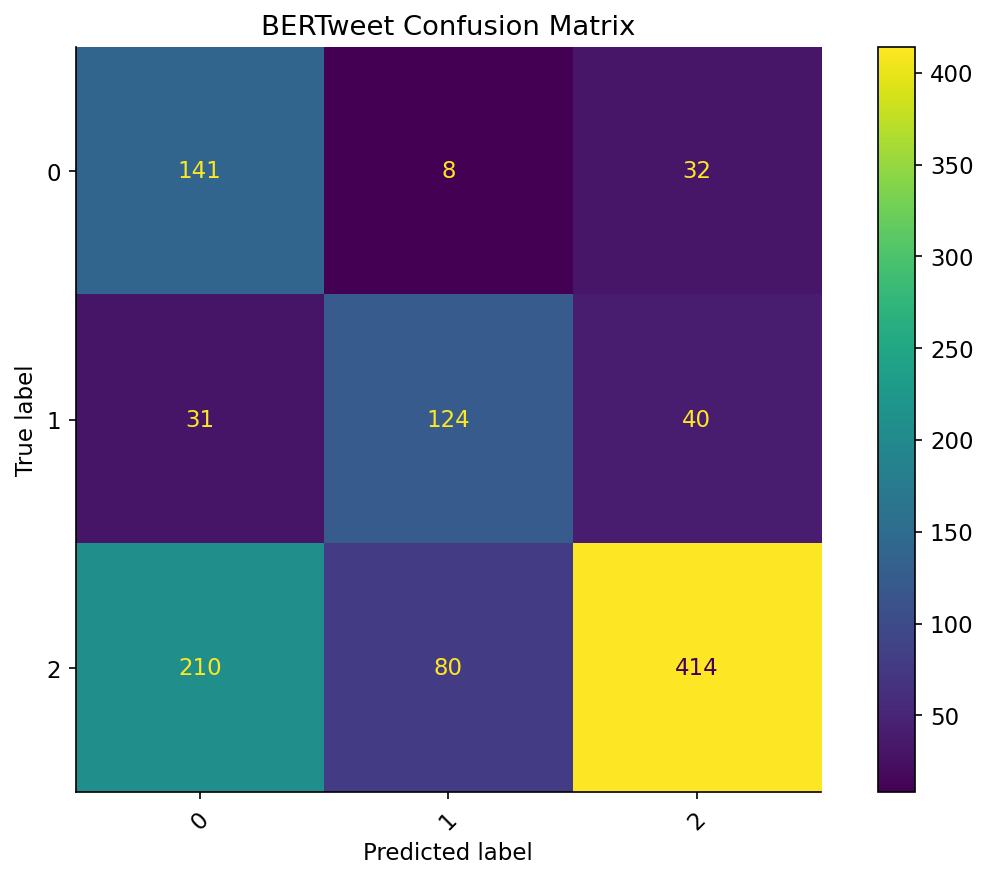

In [49]:
# =========================
# 14. Confusion matrix
# =========================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "BERTweet Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "bertweet_confusion_matrix.png",
    dpi=300
)

plt.show()

In [38]:
# =========================
# 15. Save predictions
# =========================

test_output = test_df.copy()

test_output["predicted_label_id"] = y_pred

test_output["predicted_label"] = [
    id2label[int(i)]
    for i in y_pred
]

test_output["true_label"] = [
    id2label[int(i)]
    for i in y_true
]

test_output.to_csv(
    "bertweet_test_predictions.csv",
    index=False
)

print(
    "Predictions saved successfully"
)

test_output.head()

Predictions saved successfully


,text,label,labels,predicted_label_id,predicted_label,true_label
0,Atheism [SEP] he who exalts himself shall be h...,2,2,2,2,2
1,Atheism [SEP] rt : i remove nehushtan -previou...,2,2,2,2,2
2,Atheism [SEP] i have sought the truth of my so...,2,2,2,2,2
3,Atheism [SEP] #god is utterly powerless withou...,2,2,0,0,2
4,Atheism [SEP] miracles of #multiculturalism mi...,2,2,1,1,2


In [39]:
# =========================
# 16. Save final model
# =========================

trainer.save_model(
    "./final_bertweet_model"
)

tokenizer.save_pretrained(
    "./final_bertweet_model"
)

print(
    "Model and tokenizer saved successfully"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully


In [45]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})
CLASS_NAMES = [str(id2label[i]) for i in range(len(labels))]
COLOR_MAP = {"FAVOR": "#378ADD", "NONE": "#888780", "AGAINST": "#D85A30"}
COLORS = [COLOR_MAP.get(c, "#5F5E5A") for c in CLASS_NAMES]

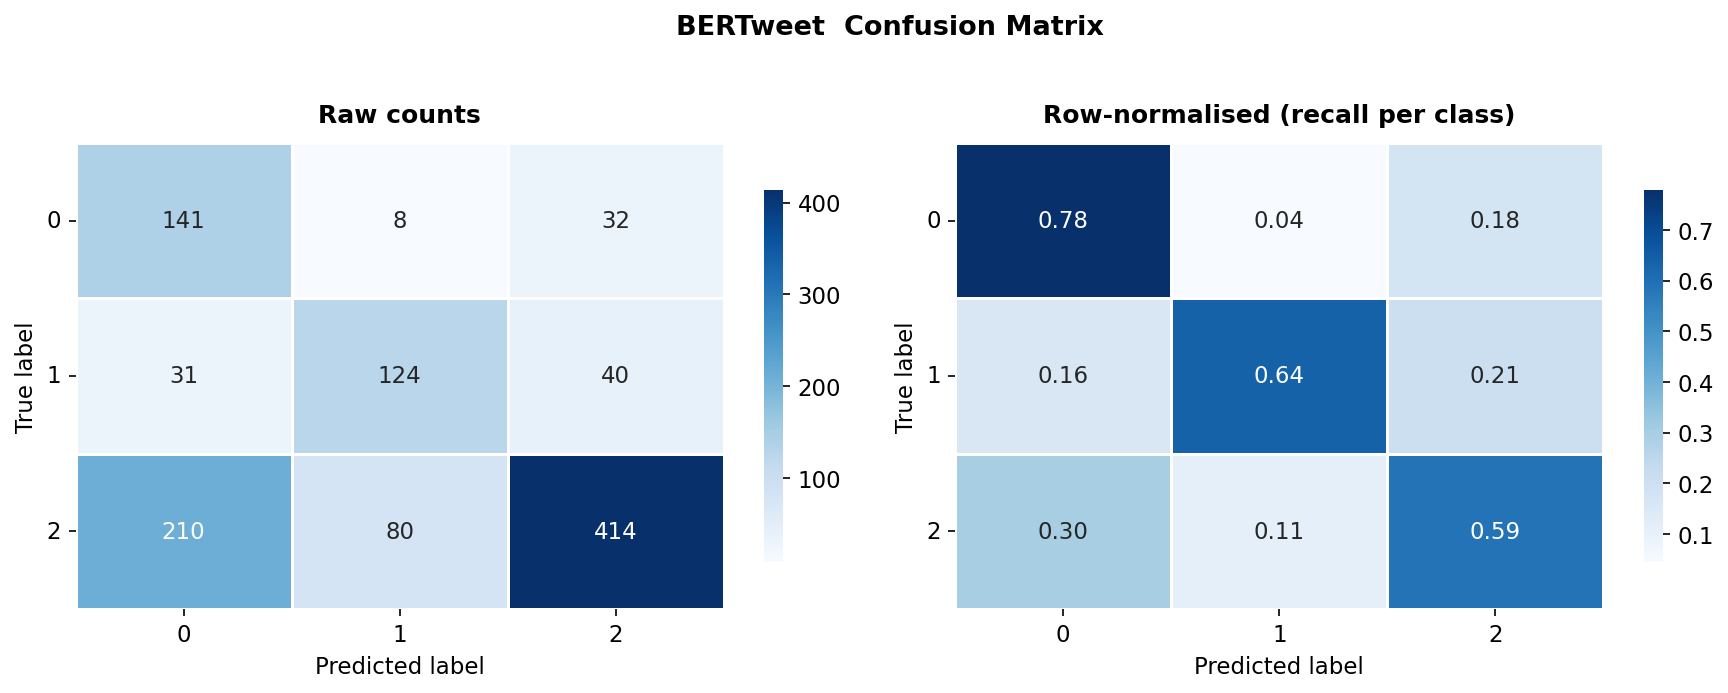

In [46]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ["d", ".2f"],
    ["Raw counts", "Row-normalised (recall per class)"]
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor="white",
        cbar_kws={"shrink": 0.8}, ax=ax
    )
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("BERTweet  Confusion Matrix", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


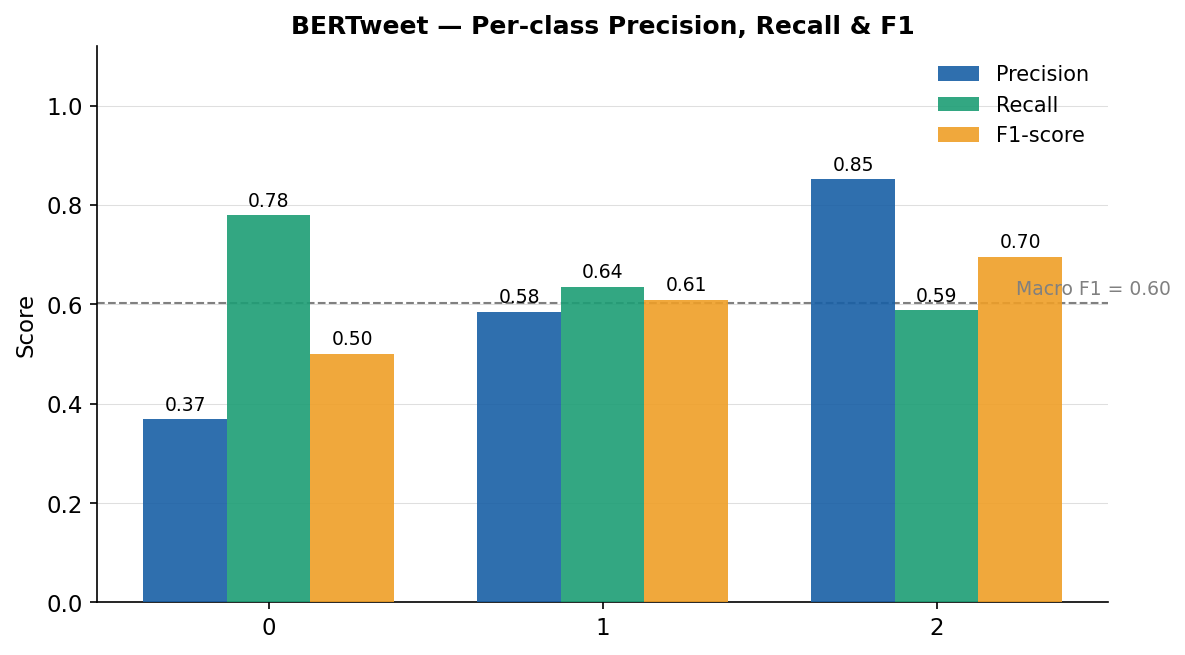

In [47]:
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

metrics   = ["precision", "recall", "f1-score"]
x         = np.arange(len(CLASS_NAMES))
bar_w     = 0.25
bar_color = ["#185FA5", "#1D9E75", "#EF9F27"]   # blue, teal, amber

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (metric, color) in enumerate(zip(metrics, bar_color)):
    vals = [report[cls][metric] for cls in CLASS_NAMES]
    bars = ax.bar(x + i * bar_w, vals, bar_w, label=metric.capitalize(),
                  color=color, alpha=0.9, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{v:.2f}", ha="center", va="bottom", fontsize=9
        )

ax.set_xticks(x + bar_w)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}"))
ax.legend(frameon=False, fontsize=10)
ax.set_title("BERTweet — Per-class Precision, Recall & F1", fontsize=12, fontweight="bold")
ax.axhline(report["macro avg"]["f1-score"], color="gray", linewidth=1,
           linestyle="--", label="Macro F1")
ax.text(len(CLASS_NAMES) - 0.05,
        report["macro avg"]["f1-score"] + 0.01,
        f'Macro F1 = {report["macro avg"]["f1-score"]:.2f}',
        ha="right", va="bottom", color="gray", fontsize=9)
ax.grid(axis="y", linewidth=0.5, alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

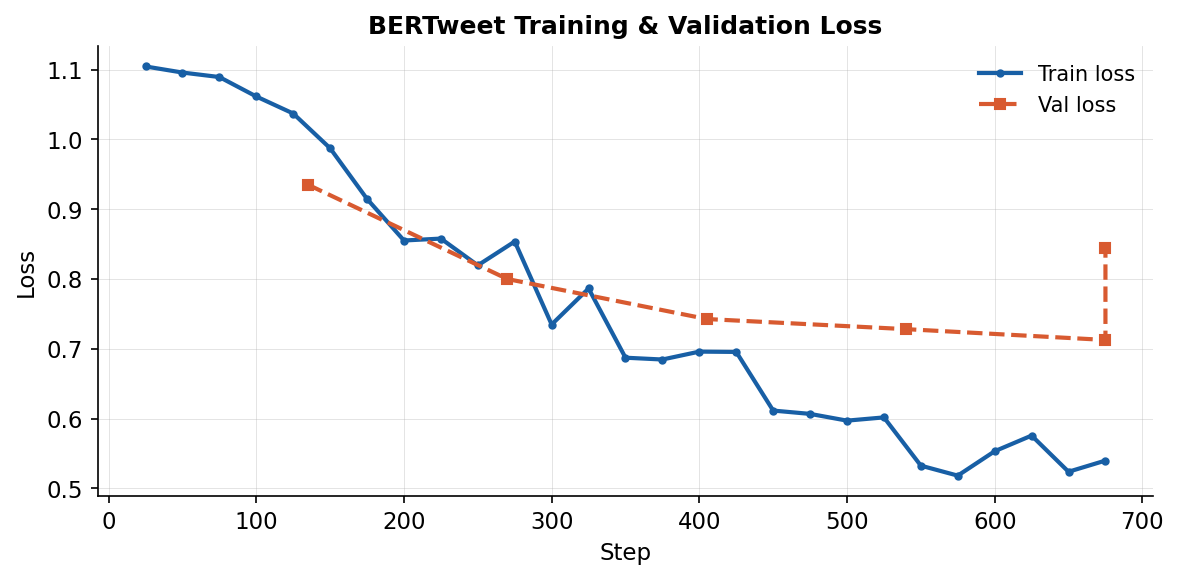

In [48]:
log_history = trainer.state.log_history

train_steps  = [e["step"] for e in log_history if "loss" in e]
train_losses = [e["loss"] for e in log_history if "loss" in e]
eval_steps   = [e["step"] for e in log_history if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log_history if "eval_loss" in e]

if train_steps:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_steps, train_losses, label="Train loss",
            color="#185FA5", linewidth=2, marker="o", markersize=3)
    if eval_steps:
        ax.plot(eval_steps, eval_losses, label="Val loss",
                color="#D85A30", linewidth=2, marker="s", markersize=5,
                linestyle="--")
    ax.set_xlabel("Step", fontsize=11)
    ax.set_ylabel("Loss", fontsize=11)
    ax.set_title("BERTweet Training & Validation Loss", fontsize=12, fontweight="bold")
    ax.legend(frameon=False, fontsize=10)
    ax.grid(linewidth=0.4, alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("No training loss logs found skipping loss curve.")

In [44]:
from scipy.special import softmax as scipy_softmax

try:
    probs       = scipy_softmax(predictions.predictions, axis=1)
    y_true_bin  = label_binarize(y_true, classes=list(range(len(labels))))

    fig, ax = plt.subplots(figsize=(7, 5))
    for i, (cls, color) in enumerate(zip(CLASS_NAMES, COLORS)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cls}  (AUC = {roc_auc:.2f})",
                color=color, linewidth=2)

    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
    ax.set_xlabel("False positive rate", fontsize=11)
    ax.set_ylabel("True positive rate", fontsize=11)
    ax.set_title("BERTweet One-vs-Rest ROC Curves", fontsize=12, fontweight="bold")
    ax.legend(frameon=False, fontsize=10)
    ax.grid(linewidth=0.4, alpha=0.4)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"ROC curves skipped: {e}")


ROC curves skipped: name 'label_binarize' is not defined
